In [1]:
import requests
import pandas as pd

In [2]:
def get_history(coin, days):

    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"

    params = {
        "vs_currency" : "jpy",
        "days": days
    }

    response = requests.get(url,params=params)

    data = response.json()

    df = pd.DataFrame(
        data["prices"],
        columns=["Timestamp", "Price"]
    )

    df["Date"] = pd.to_datetime(
        df["Timestamp"],
        unit="ms"
    )

    df["Coin"] = coin

    return df.drop(columns="Timestamp")

In [3]:
coins = [
    "bitcoin",
    "ethereum",
    "solana"
]

all_df = []

for coin in coins:

    df = get_history(coin, 365)

    all_df.append(df)

crypto_df = pd.concat(
    all_df,
    ignore_index=True
)


In [4]:
crypto_df

,Price,Date,Coin
0,1.698070e+07,2025-08-05 00:00:00,bitcoin
1,1.679588e+07,2025-08-06 00:00:00,bitcoin
2,1.688483e+07,2025-08-07 00:00:00,bitcoin
3,1.734690e+07,2025-08-08 00:00:00,bitcoin
4,1.722354e+07,2025-08-09 00:00:00,bitcoin
...,...,...,...
1093,1.147372e+04,2026-08-01 00:00:00,solana
1094,1.131875e+04,2026-08-02 00:00:00,solana
1095,1.158123e+04,2026-08-03 00:00:00,solana
1096,1.157764e+04,2026-08-04 00:00:00,solana


前処理

In [5]:
crypto_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   1098 non-null   float64       
 1   Date    1098 non-null   datetime64[ns]
 2   Coin    1098 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.9+ KB


In [6]:
crypto_df.head()

,Price,Date,Coin
0,1.698070e+07,2025-08-05,bitcoin
1,1.679588e+07,2025-08-06,bitcoin
2,1.688483e+07,2025-08-07,bitcoin
3,1.734690e+07,2025-08-08,bitcoin
4,1.722354e+07,2025-08-09,bitcoin


In [7]:
crypto_df.describe()

,Price,Date
count,1.098000e+03,1098
mean,4.588430e+06,2026-02-03 11:59:45.227686912
min,9.968505e+03,2025-08-05 00:00:00
25%,2.506253e+04,2025-11-04 00:00:00
50%,3.785534e+05,2026-02-03 12:00:00
75%,1.070969e+07,2026-05-06 00:00:00
max,1.896351e+07,2026-08-04 22:30:00
std,6.354822e+06,NaN


In [8]:
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"])
crypto_df["Year"] = crypto_df["Date"].dt.year
crypto_df["Month"] = crypto_df["Date"].dt.month
crypto_df["Weekday"] = crypto_df["Date"].dt.day_name()

crypto_df

,Price,Date,Coin,Year,Month,Weekday
0,1.698070e+07,2025-08-05 00:00:00,bitcoin,2025,8,Tuesday
1,1.679588e+07,2025-08-06 00:00:00,bitcoin,2025,8,Wednesday
2,1.688483e+07,2025-08-07 00:00:00,bitcoin,2025,8,Thursday
3,1.734690e+07,2025-08-08 00:00:00,bitcoin,2025,8,Friday
4,1.722354e+07,2025-08-09 00:00:00,bitcoin,2025,8,Saturday
...,...,...,...,...,...,...
1093,1.147372e+04,2026-08-01 00:00:00,solana,2026,8,Saturday
1094,1.131875e+04,2026-08-02 00:00:00,solana,2026,8,Sunday
1095,1.158123e+04,2026-08-03 00:00:00,solana,2026,8,Monday
1096,1.157764e+04,2026-08-04 00:00:00,solana,2026,8,Tuesday


土日と平日で違いはある？

In [9]:
crypto_df["DayType"] = crypto_df["Weekday"].apply(
    lambda x:"Weekend"
    if x in ["Saturday","Sunday"]
    else "Weekday"
)
crypto_df

,Price,Date,Coin,Year,Month,Weekday,DayType
0,1.698070e+07,2025-08-05 00:00:00,bitcoin,2025,8,Tuesday,Weekday
1,1.679588e+07,2025-08-06 00:00:00,bitcoin,2025,8,Wednesday,Weekday
2,1.688483e+07,2025-08-07 00:00:00,bitcoin,2025,8,Thursday,Weekday
3,1.734690e+07,2025-08-08 00:00:00,bitcoin,2025,8,Friday,Weekday
4,1.722354e+07,2025-08-09 00:00:00,bitcoin,2025,8,Saturday,Weekend
...,...,...,...,...,...,...,...
1093,1.147372e+04,2026-08-01 00:00:00,solana,2026,8,Saturday,Weekend
1094,1.131875e+04,2026-08-02 00:00:00,solana,2026,8,Sunday,Weekend
1095,1.158123e+04,2026-08-03 00:00:00,solana,2026,8,Monday,Weekday
1096,1.157764e+04,2026-08-04 00:00:00,solana,2026,8,Tuesday,Weekday


In [10]:
result = (
    crypto_df.groupby("DayType")["Price"]
    .mean()
    .round(2)
)

print(result)

DayType
Weekday    4596741.07
Weekend    4567490.83
Name: Price, dtype: float64


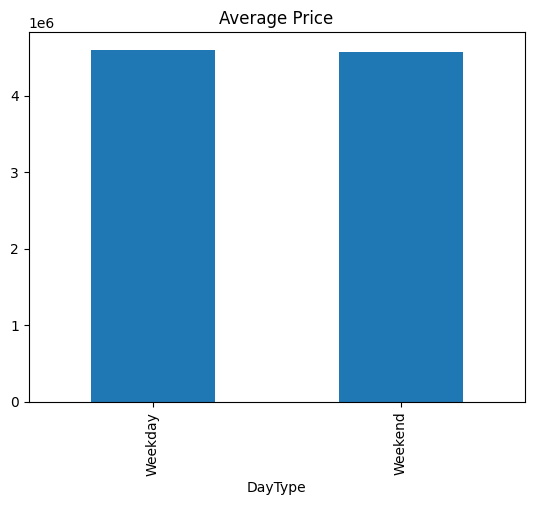

In [11]:
import matplotlib.pyplot as plt

result.plot(kind="bar")
plt.title("Average Price")

plt.show()

大きく下がった日の共通点

In [12]:
crypto_df["Return"] = (
    crypto_df.groupby("Coin")["Price"]
             .pct_change()
             *100
)

In [13]:
big_drop = (
    crypto_df.nsmallest(
        10,
        "Return"
    )
)

print(
    big_drop[
        [
            "Date",
            "Price",
            "Return"
        ]
    ]
)

          Date         Price     Return
551 2026-02-06  2.867031e+05 -14.692598
917 2026-02-06  1.232520e+04 -14.616535
799 2025-10-11  2.854450e+04 -14.555439
185 2026-02-06  9.868767e+06 -13.856195
433 2025-10-11  5.808419e+05 -12.058049
823 2025-11-04  2.546857e+04 -11.995828
671 2026-06-06  2.536762e+05 -10.546611
912 2026-02-01  1.636845e+04  -9.959873
753 2025-08-26  2.760677e+04  -9.307003
546 2026-02-01  3.802492e+05  -9.088447


月ごとの平均価格

In [14]:
monthly = (
    crypto_df.groupby(crypto_df["Date"].dt.month)["Price"]
    .mean()
    .round()
)

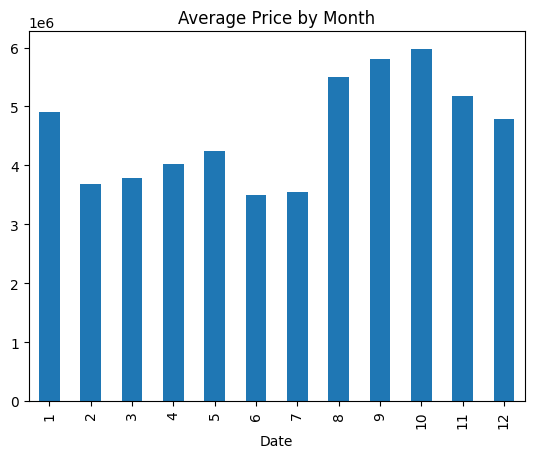

In [15]:
monthly.plot(
    kind="bar"
)

plt.title(
    "Average Price by Month"
)

plt.show()

どの年のボラティリティが大きい？

In [16]:
volatility = (
    crypto_df.groupby("Year")["Return"]
      .std()
      .round(2)
)

print(volatility)

Year
2025    3.39
2026    3.04
Name: Return, dtype: float64


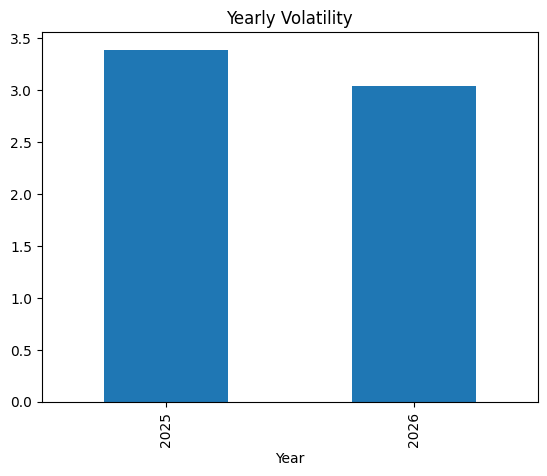

In [17]:
volatility.plot(
    kind="bar"
)

plt.title(
    "Yearly Volatility"
)

plt.show()

銘柄別ボラティリティ

In [18]:
volatility_coin = (
    crypto_df.groupby("Coin")["Return"]
      .std()
      .round(2)
)

print(volatility_coin)

Coin
bitcoin     2.27
ethereum    3.45
solana      3.67
Name: Return, dtype: float64


曜日ごとの平均リターン

In [19]:
big_drop_weekday = (
    crypto_df.groupby("Weekday")["Return"]
      .mean()
      .round(2)
)

print(big_drop_weekday)

Weekday
Friday      -1.21
Monday       0.20
Saturday    -0.10
Sunday       0.02
Thursday     0.27
Tuesday      0.21
Wednesday   -0.25
Name: Return, dtype: float64


30日移動平均線（MA30）

In [20]:
crypto_df["MA30"] = (
    crypto_df
    .groupby("Coin")["Price"]
    .transform(
        lambda x:
        x.rolling(30).mean()
    )
)

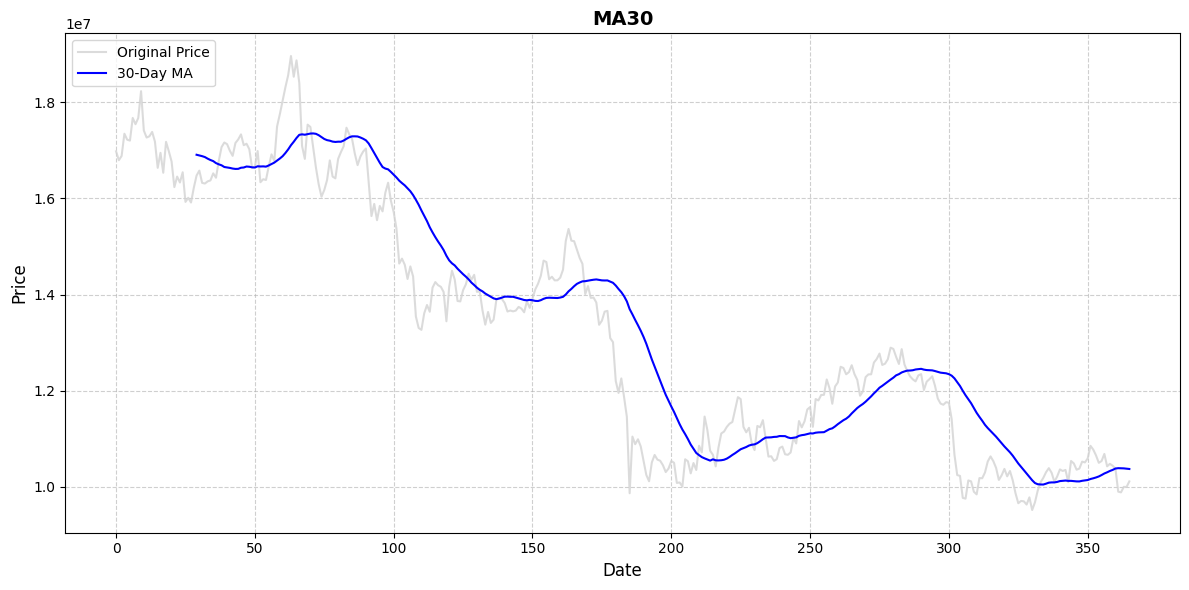

In [22]:
btc = crypto_df[
    crypto_df["Coin"]=="bitcoin"
]

plt.figure(figsize=(12, 6))

plt.plot(btc["Price"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(btc["MA30"], label="30-Day MA", color="blue", linewidth=1.5)

plt.title("MA30", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

前日の価格

In [ ]:
crypto_df["Price_Yesterday"] = (
    crypto_df
    .groupby("Coin")["Price"]
    .shift(1)
)

7日移動平均